In [8]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
import matplotlib.pyplot as plt

In [11]:
# ============================================================
# 1. LOAD DATA
# ============================================================
# Adjust these file names if your .npy names are different
X_train = np.load("X_train.npy")
y_train = np.load("y_train.npy")
X_test  = np.load("X_test.npy")
y_test  = np.load("y_test.npy")
X_eval = np.load("X_eval.npy")
y_eval = np.load("y_eval.npy")


print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

timesteps = X_train.shape[1]
features  = X_train.shape[2]

X_train shape: (41427, 24, 35)
y_train shape: (41427,)
X_test shape: (8713, 24, 35)
y_test shape: (8713,)


In [3]:
# ============================================================
# 2. BUILD TCN MODEL
# ============================================================

def build_tcn(
    timesteps,
    features,
    num_filters=64,
    kernel_size=3,
    dilations=(1, 2, 4, 8),
    dropout_rate=0.2,
):
    inputs = layers.Input(shape=(timesteps, features))
    x = inputs

    for d in dilations:
        # Causal Conv1D
        conv = layers.Conv1D(
            filters=num_filters,
            kernel_size=kernel_size,
            dilation_rate=d,
            padding="causal",
            activation="relu",
        )(x)
        conv = layers.Dropout(dropout_rate)(conv)

        # Residual connection (1x1 conv if channels differ)
        if x.shape[-1] != num_filters:
            res = layers.Conv1D(num_filters, kernel_size=1, padding="same")(x)
        else:
            res = x

        x = layers.Add()([conv, res])
        x = layers.LayerNormalization()(x)

    # Pool over time and predict single next value (1-hour ahead)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(32, activation="relu")(x)
    outputs = layers.Dense(1)(x)

    model = models.Model(inputs, outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="mse",
        metrics=["mae"],
    )
    return model


model = build_tcn(timesteps, features)
model.summary()


2025-12-04 21:18:46.418195: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 24, 35)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 24, 64)    │      6,784 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 24, 64)    │          0 │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 24, 64)    │      2,304 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 24, 64)    │          0 │ dropout[0][0],    │
│                     │                   │            │ conv1d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 24, 64)    │        128 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 24, 64)    │     12,352 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 24, 64)    │          0 │ conv1d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 24, 64)    │          0 │ dropout_1[0][0],  │
│                     │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 24, 64)    │        128 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 24, 64)    │     12,352 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 24, 64)    │          0 │ conv1d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 24, 64)    │          0 │ dropout_2[0][0],  │
│                     │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 24, 64)    │        128 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 24, 64)    │     12,352 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 24, 64)    │          0 │ conv1d_4[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 24, 64)    │          0 │ dropout_3[0][0],  │
│                     │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 24, 64)    │        128 │ add_3[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 32)        │      2,080 │ global_average_p

 Total params: 48,769 (190.50 KB)

 Trainable params: 48,769 (190.50 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
# ============================================================
# 3. TRAIN
# ============================================================

early_stop = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1,
)

Epoch 1/50
648/648 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 0.2617 - mae: 0.2899 - val_loss: 0.3361 - val_mae: 0.4130
Epoch 2/50
648/648 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - loss: 0.0611 - mae: 0.1440 - val_loss: 0.2799 - val_mae: 0.3382
Epoch 3/50
648/648 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - loss: 0.0461 - mae: 0.1233 - val_loss: 0.2685 - val_mae: 0.3274
Epoch 4/50
648/648 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - loss: 0.0436 - mae: 0.1173 - val_loss: 0.2146 - val_mae: 0.2975
Epoch 5/50
648/648 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - loss: 0.0392 - mae: 0.1106 - val_loss: 0.2166 - val_mae: 0.2835
Epoch 6/50
648/648 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - loss: 0.0350 - mae: 0.1035 - val_loss: 0.2068 - val_mae: 0.2750
Epoch 7/50
648/648 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - loss: 0.0338 - mae: 0.1013 - val_loss: 0.2020 - val_mae: 0.2575
Epoch 8/50
648/648 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - loss: 0.0301 - mae: 0.0944 - val_loss: 0.1900 - val_mae: 0.2582
Epoch 9/50
648/648 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms

In [5]:
# ============================================================
# 4. EVALUATE
# ============================================================

test_loss, test_mae = model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest loss: {test_loss:.6f}")
print(f"Test MAE : {test_mae:.6f}")


Test loss: 0.155492
Test MAE : 0.229647


In [6]:
model.save("tcn_model.keras")
print("\nSaved 1-hour TCN model as tcn_model.keras")


Saved 1-hour TCN model as tcn_model.keras


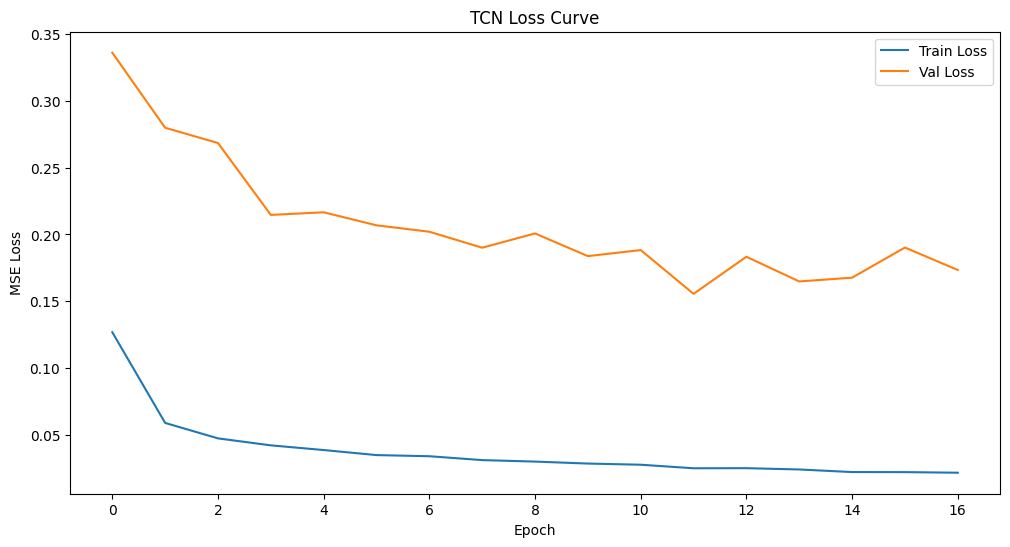

In [9]:
# ============================================================
# 5. PLOT TRAINING CURVE
# ============================================================

plt.figure(figsize=(12, 6))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("TCN Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.show()


Plotting dynamic segment starting at index 200
181/181 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


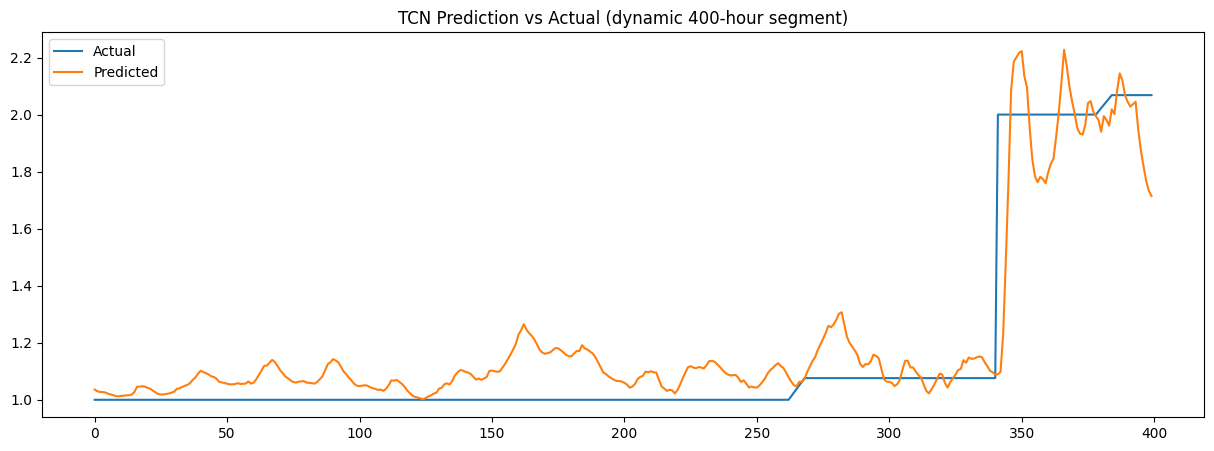

In [12]:
# ============================================================
# 6. SMART PREDICTION PLOT
#    (auto-detects a non-flat segment from eval data)
# ============================================================

# Find a region where y_eval varies more than ±0.15 (adjust threshold for your scale)
window = 400   # look for 400-hour segments
start_idx = 0
for i in range(0, len(y_eval) - window, 100):
    segment = y_eval[i:i + window]
    if segment.max() - segment.min() > 0.15:
        start_idx = i
        break

print(f"\nPlotting dynamic segment starting at index {start_idx}")

y_pred = model.predict(X_eval).flatten()

plt.figure(figsize=(15, 5))
plt.plot(y_eval[start_idx:start_idx + 400], label="Actual")
plt.plot(y_pred[start_idx:start_idx + 400], label="Predicted")
plt.title("TCN Prediction vs Actual (dynamic 400-hour segment)")
plt.legend()
plt.show()


Loading TCN model...
Loading X_eval and y_eval...
Shapes:
X_eval: (5785, 24, 35)
y_eval: (5785,)
Generating predictions...
181/181 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Predictions saved as y_pred_tcn.npy


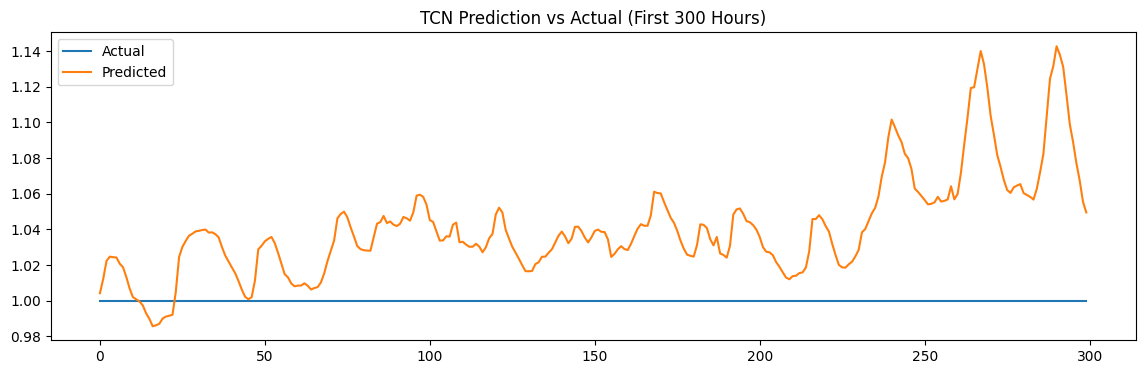

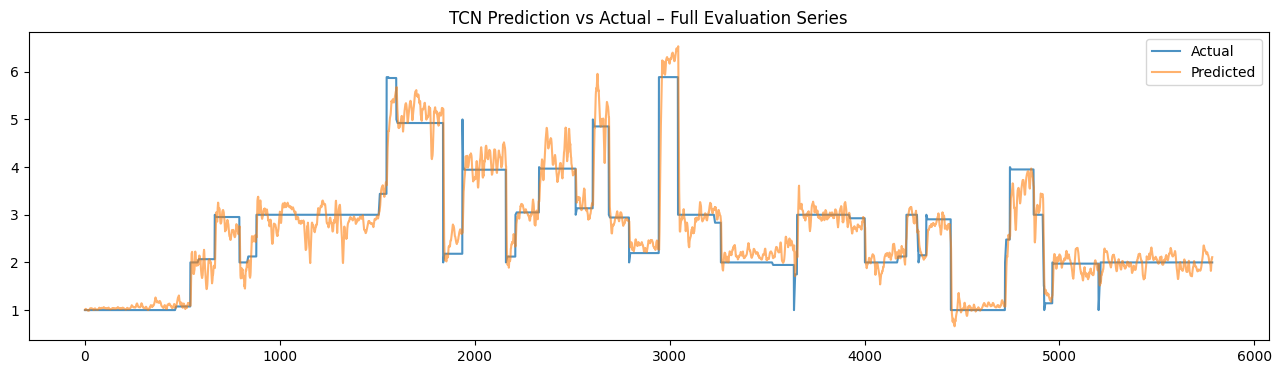

In [13]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

# --------------------------------------------------------
# 1. Load Saved TCN Model
# --------------------------------------------------------
print("Loading TCN model...")
model = tf.keras.models.load_model("tcn_model.keras")

# --------------------------------------------------------
# 2. Load Preprocessed Windowed Data
# --------------------------------------------------------
print("Loading X_eval and y_eval...")
X_eval = np.load("X_eval.npy")
y_eval = np.load("y_eval.npy")

print("Shapes:")
print("X_eval:", X_eval.shape)
print("y_eval:", y_eval.shape)

# --------------------------------------------------------
# 3. Run Predictions
# --------------------------------------------------------
print("Generating predictions...")
y_pred = model.predict(X_eval, verbose=1)

# Flatten predictions if needed (Keras outputs shape (n, 1))
y_pred = y_pred.reshape(-1)

# Save predictions to a file (for plots and documentation)
np.save("y_pred_tcn.npy", y_pred)

print("Predictions saved as y_pred_tcn.npy")

# --------------------------------------------------------
# 4. Plot FIRST 300 HOURS (quick check)
# --------------------------------------------------------
plt.figure(figsize=(14, 4))
plt.plot(y_eval[:300], label="Actual")
plt.plot(y_pred[:300], label="Predicted")
plt.title("TCN Prediction vs Actual (First 300 Hours)")
plt.legend()
plt.show()

# --------------------------------------------------------
# 5. Plot FULL Test/Eval Curve
# --------------------------------------------------------
plt.figure(figsize=(16, 4))
plt.plot(y_eval, label="Actual", alpha=0.8)
plt.plot(y_pred, label="Predicted", alpha=0.6)
plt.title("TCN Prediction vs Actual – Full Evaluation Series")
plt.legend()
plt.show()


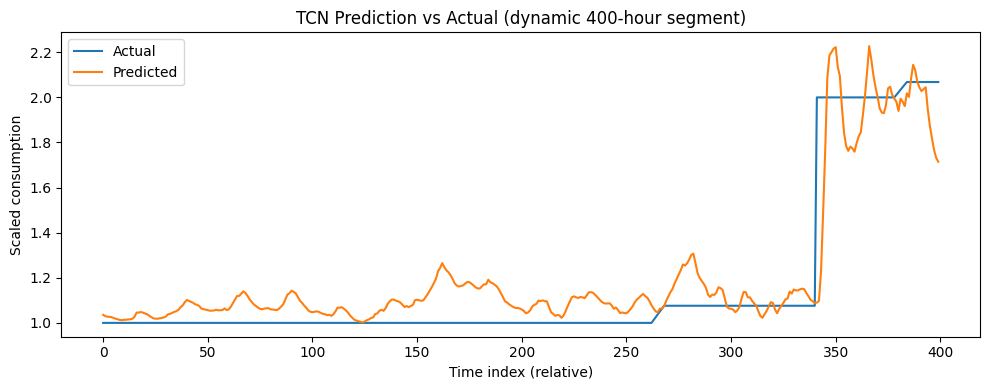

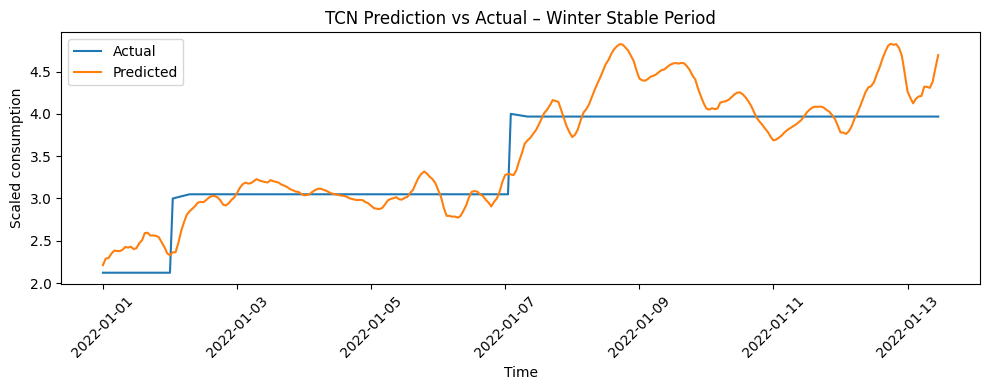

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Paths (adjust if needed)
X_EVAL_PATH = "X_eval.npy"
Y_EVAL_PATH = "y_eval.npy"
Y_PRED_PATH = "y_pred_tcn.npy"  # <-- TCN predictions
DATA_CSV_PATH = "dataset_mansion_features.csv"

# Load arrays and dataset
X_eval = np.load(X_EVAL_PATH)
y_eval = np.load(Y_EVAL_PATH)
y_pred = np.load(Y_PRED_PATH)
df = pd.read_csv(DATA_CSV_PATH, parse_dates=["MTime"])

# ---------- Plot 1: Zoomed 400-hour segment ----------
start = 200
window = 400

plt.figure(figsize=(10, 4))
plt.plot(y_eval[start:start+window], label="Actual")
plt.plot(y_pred[start:start+window], label="Predicted")
plt.title("TCN Prediction vs Actual (dynamic 400-hour segment)")
plt.xlabel("Time index (relative)")
plt.ylabel("Scaled consumption")
plt.legend()
plt.tight_layout()
plt.savefig("tcn_zoomed_segment.png", dpi=200)
plt.show()

# ---------- Plot 2: Winter stable period ----------
df_eval = df[(df["MTime"] >= "2021-10-01") & (df["MTime"] <= "2022-05-31")].sort_values("MTime")

# Align timestamps with y_eval length
if len(df_eval) >= len(y_eval):
    df_eval_aligned = df_eval.tail(len(y_eval)).copy()
else:
    df_eval_aligned = df_eval.copy()
    y_eval = y_eval[-len(df_eval_aligned):]
    y_pred = y_pred[-len(df_eval_aligned):]

df_eval_aligned["actual"] = y_eval[:len(df_eval_aligned)]
df_eval_aligned["pred"] = y_pred[:len(df_eval_aligned)]

winter_df = df_eval_aligned[df_eval_aligned["MTime"].dt.month.isin([1, 2])]
winter_window = 300
winter_slice = winter_df.head(winter_window)

plt.figure(figsize=(10, 4))
plt.plot(winter_slice["MTime"], winter_slice["actual"], label="Actual")
plt.plot(winter_slice["MTime"], winter_slice["pred"], label="Predicted")
plt.title("TCN Prediction vs Actual – Winter Stable Period")
plt.xlabel("Time")
plt.ylabel("Scaled consumption")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig("tcn_winter_segment.png", dpi=200)
plt.show()
